과제
---------
sklearn 의 breast_cancer 데이터셋

1. train, test 나누기
2. 정규화
3. 케라스 학습
4. train, test 각각 confusion matrix(heat map 포함), f1, acc
5. 1번째행 예측값

In [82]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression, LinearRegression,SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_breast_cancer

import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import seaborn as sb
matplotlib.rcParams['font.family']='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False


In [83]:
cancer = load_breast_cancer(as_frame=True)
cancer['frame']

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [84]:
x_data = cancer['data']
y_data = cancer['target']

In [85]:
x_data.shape

(569, 30)

In [86]:
y_data.shape

(569,)

In [87]:
y_data

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64

1. train, test 나누기

In [88]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42, stratify=y_data)

In [89]:
y_train.shape

(455,)

2. 정규화

In [90]:
scale = StandardScaler()
x_train_s = scale.fit_transform(x_train)
x_test_s = scale.transform(x_test)

In [91]:
y_train_n = np.array(y_train, np.float32)
y_test_n = np.array(y_test, np.float32)

In [92]:
x_train_s.shape

(455, 30)

In [93]:
y_train_n.shape

(455,)

In [94]:
dense = Dense(units=1, input_dim=30, activation='sigmoid')
model = Sequential( [dense] )
model.compile(loss='binary_crossentropy', optimizer=Adam(0.1), metrics=['acc']) # acc : 정확도를 출력해줌
h = model.fit(x_train_s, y_train_n, epochs=500)

Epoch 1/500


c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9648 - loss: 0.1262  
Epoch 2/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9758 - loss: 0.0765 
Epoch 3/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9824 - loss: 0.0616 
Epoch 4/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9824 - loss: 0.0604 
Epoch 5/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9824 - loss: 0.0619 
Epoch 6/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9824 - loss: 0.0699 
Epoch 7/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9736 - loss: 0.0651 
Epoch 8/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9846 - loss: 0.0570 
Epoch 9/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9846 - loss: 0.0518 
Epoch 10/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9824 - loss: 0.0530 
Epoch 11/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9868 - loss: 0.0491 
Epoch 12/500
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9824 - loss: 0.0513 
Epoch 13/500
15/15 ━━━━━━━━━━━━━━━━━

In [95]:
pred_tr = (model.predict(x_train_s) > 0.5) + 0

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [96]:
pred_tt = (model.predict(x_test_s) > 0.5) + 0

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


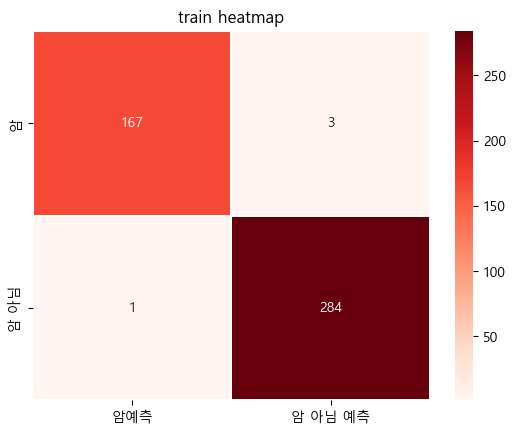

In [97]:
c_tr = confusion_matrix(y_train_n, pred_tr)

sb.heatmap(c_tr, annot=True, fmt='d', linewidths=0.2, cmap='Reds',
            xticklabels=['암예측','암 아님 예측'],
            yticklabels=['암','암 아님'])
plt.title('train heatmap')
plt.show()

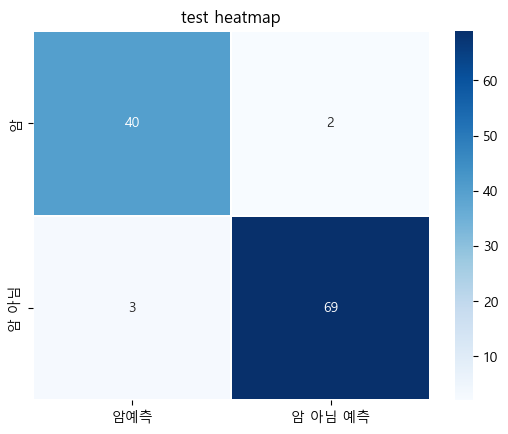

In [98]:
c_tt = confusion_matrix(y_test_n, pred_tt)

sb.heatmap(c_tt, annot=True, fmt='d', linewidths=0.2, cmap='Blues',
            xticklabels=['암예측','암 아님 예측'],
            yticklabels=['암','암 아님'])
plt.title('test heatmap')
plt.show()

f1, acc

In [99]:
print('f1_score(Train)', f1_score(y_train_n, pred_tr))
print('f1_score(Test)', f1_score(y_test_n, pred_tt))

f1_score(Train) 0.993006993006993
f1_score(Test) 0.965034965034965


In [100]:
print('accuracy_score(Train)',accuracy_score(y_train_n, pred_tr))
print('accuracy_score(Test)',accuracy_score(y_test_n, pred_tt))

accuracy_score(Train) 0.9912087912087912
accuracy_score(Test) 0.956140350877193


In [101]:
h.history['acc'][-1]

0.9890109896659851

1 번째 행 에측값 

In [114]:
xd = scale.transform( x_data.iloc[0].values.reshape(1,-1) )
(model.predict( xd) >0.5) + 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


c:\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0]])